# Is the "Europe" audience-region read an artifact of excluding English?

**Purpose**: `creator_crossover_community_detection.ipynb`'s audience-region variable excludes `en`/`es`/`zh`/`ar`/`other` as too linguistically ambiguous to place on one region (following `title_geography_maps.ipynb`'s own precedent). This notebook tests a specific, plausible failure mode of that choice directly: if a title's audience is mostly English, excluding English doesn't just lower coverage — it can hand the "dominant region" title to whatever's left, and Europe's language roster (German, French, Italian, Polish, Turkish, Czech, Hungarian, Greek, Finnish, Swedish, Danish, Norwegian, Dutch, Romanian, Bulgarian, Slovak, Croatian — 17 mapped languages) gives it far more chances to win that leftover contest than Latin America (1 mapped language: Portuguese), CIS (2: Russian, Ukrainian), or MENA (1: Hebrew). If that's what's happening, "Europe" isn't measuring European audience share, it's measuring "not-English-not-Spanish-and-Europe-had-more-lottery-tickets."

In [1]:
# Imports and repo path setup -- same pattern as every other notebook.
import sys
from pathlib import Path

def _find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "CLAUDE.md").is_file():
            return candidate
    raise RuntimeError("Could not find repo root (CLAUDE.md not found in any parent directory) -- run this notebook from somewhere inside the repo")

REPO_ROOT = _find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from scipy.stats import pointbiserialr, pearsonr

from etl.db import get_connection

with open(REPO_ROOT / "config" / "titles.yaml") as f:
    titles_config = yaml.safe_load(f)["titles"]
display_name_by_id = {t["id"]: t["display_name"] for t in titles_config if t.get("is_active")}
all_title_ids = sorted(display_name_by_id.keys())

In [2]:
# Identical LANGUAGE_TO_REGION mapping to creator_crossover_community_detection.ipynb
# -- reused verbatim, not redefined, so this test is checking the actual
# mapping in use, not a stand-in for it.
LANGUAGE_TO_REGION = {
    "ko": "Asia-Pacific", "ja": "Asia-Pacific", "th": "Asia-Pacific", "vi": "Asia-Pacific",
    "id": "Asia-Pacific", "tl": "Asia-Pacific", "hi": "Asia-Pacific", "ms": "Asia-Pacific",
    "he": "MENA",
    "ru": "CIS", "uk": "CIS",
    "de": "Europe", "fr": "Europe", "it": "Europe", "pl": "Europe", "tr": "Europe",
    "cs": "Europe", "hu": "Europe", "el": "Europe", "fi": "Europe", "sv": "Europe",
    "da": "Europe", "no": "Europe", "nl": "Europe", "ro": "Europe", "bg": "Europe",
    "sk": "Europe", "hr": "Europe",
    "pt": "Latin America",
}

n_langs_by_region = pd.Series(LANGUAGE_TO_REGION).value_counts()
print("Mapped languages per region -- the granularity imbalance itself, before any data:")
print(n_langs_by_region)

conn = get_connection()
lang_rows = conn.execute(
    "SELECT title_id, language_code, SUM(viewer_count) AS viewer_time FROM language_mix_snapshots "
    "WHERE title_id IN ({}) GROUP BY title_id, language_code".format(",".join("?" * len(all_title_ids))),
    all_title_ids,
).fetchall()
conn.close()

lang_df = pd.DataFrame(lang_rows, columns=["title_id", "language_code", "viewer_time"])
lang_df["region"] = lang_df["language_code"].map(LANGUAGE_TO_REGION)
title_totals = lang_df.groupby("title_id")["viewer_time"].sum()

Mapped languages per region -- the granularity imbalance itself, before any data:
Europe           17
Asia-Pacific      8
CIS               2
MENA              1
Latin America     1
Name: count, dtype: int64


In [3]:
# Item 2: per-title report -- dominant region, coverage, AND the raw
# excluded-language shares that actually drive coverage, so the
# relationship is visible directly rather than inferred from coverage as
# a proxy.
def lang_share(code: str) -> pd.Series:
    return (lang_df[lang_df["language_code"] == code].groupby("title_id")["viewer_time"].sum() / title_totals * 100).reindex(all_title_ids).fillna(0.0)

en_share = lang_share("en")
es_share = lang_share("es")
mapped_pct = (lang_df[lang_df["region"].notna()].groupby("title_id")["viewer_time"].sum() / title_totals * 100).reindex(all_title_ids).fillna(0.0)

dominant_region = {}
for t in all_title_ids:
    sub = lang_df[(lang_df["title_id"] == t) & lang_df["region"].notna()]
    dominant_region[t] = sub.groupby("region")["viewer_time"].sum().idxmax() if sub["viewer_time"].sum() > 0 else "Unclassified"

report = pd.DataFrame({
    "title": [display_name_by_id[t] for t in all_title_ids],
    "dominant_region": [dominant_region[t] for t in all_title_ids],
    "pct_mapped": mapped_pct.round(1).values,
    "en_share_pct": en_share.round(1).values,
    "es_share_pct": es_share.round(1).values,
}).sort_values("pct_mapped").reset_index(drop=True)

report

,title,dominant_region,pct_mapped,en_share_pct,es_share_pct
0,Age of Empires II,Europe,10.6,79.8,6.7
1,Rainbow Six Siege,Europe,14.8,83.0,1.2
2,Mortal Kombat 1,CIS,15.7,80.3,4.0
3,StarCraft II,Europe,18.3,78.1,2.3
4,Guilty Gear -Strive-,Asia-Pacific,19.9,73.6,6.1
5,Overwatch,Asia-Pacific,20.8,70.1,5.0
6,Tekken 8,Europe,21.3,76.9,1.2
7,Fortnite,Europe,26.2,63.2,10.2
8,Free Fire,Latin America,30.3,15.4,54.0
9,Rocket League,Europe,34.1,44.6,16.0


In [4]:
# Item 1: does low coverage predict a "Europe" read? Point-biserial
# correlation (Europe vs. not, against continuous coverage) rather than
# eyeballing the sorted table above.
is_europe = (report["dominant_region"] == "Europe").astype(int)
r_cov, p_cov = pointbiserialr(is_europe, report["pct_mapped"])
r_en, p_en = pointbiserialr(is_europe, report["en_share_pct"])
r_sanity, p_sanity = pearsonr(report["pct_mapped"], report["en_share_pct"])

print(f"Point-biserial r (dominant region = Europe, vs. pct_mapped): {r_cov:.3f}, p={p_cov:.3f}")
print(f"Point-biserial r (dominant region = Europe, vs. en_share_pct): {r_en:.3f}, p={p_en:.3f}")
print(f"Pearson r (pct_mapped vs. en_share_pct, sanity check on the mechanism): {r_sanity:.3f}, p={p_sanity:.5f}")
print()
print("Mean coverage and English share by dominant region:")
report.groupby("dominant_region")[["pct_mapped", "en_share_pct"]].agg(["mean", "count"]).round(1)

Point-biserial r (dominant region = Europe, vs. pct_mapped): -0.509, p=0.013
Point-biserial r (dominant region = Europe, vs. en_share_pct): 0.409, p=0.053
Pearson r (pct_mapped vs. en_share_pct, sanity check on the mechanism): -0.883, p=0.00000

Mean coverage and English share by dominant region:


pct_mapped       en_share_pct      
                      mean count         mean count
dominant_region                                    
Asia-Pacific          42.1     4         51.0     4
CIS                   63.6     7         30.4     7
Europe                29.7    10         56.4    10
Latin America         48.6     2         18.6     2

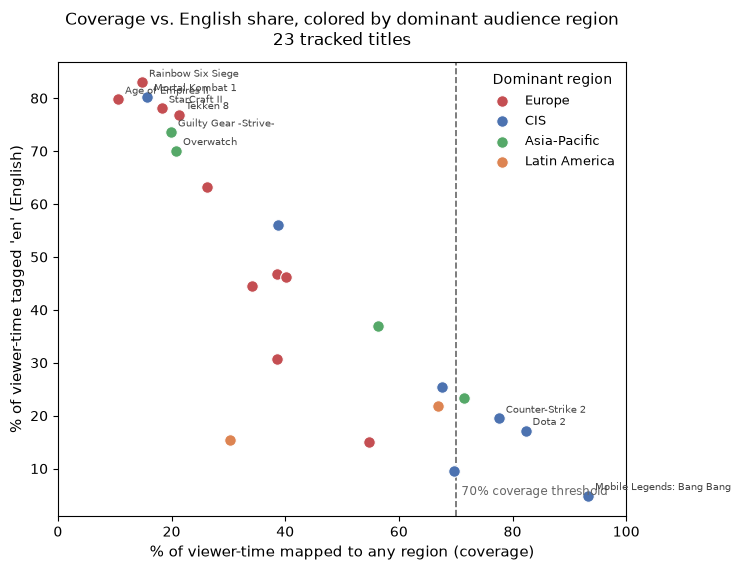

In [5]:
# Same relationship, as a chart -- coverage (x) vs. English share (y),
# colored by dominant region. If the artifact is real, "Europe" points
# should cluster in the low-coverage, high-English-share corner (top left)
# rather than being scattered evenly across the plot.
REGION_COLORS = {
    "Europe": "#C44E52", "CIS": "#4C72B0", "Asia-Pacific": "#55A868",
    "Latin America": "#DD8452", "Unclassified": "#999999",
}
COVERAGE_THRESHOLD = 70

fig, ax = plt.subplots(figsize=(7.5, 5.8))
for region, color in REGION_COLORS.items():
    sub = report[report["dominant_region"] == region]
    if len(sub) == 0:
        continue
    ax.scatter(sub["pct_mapped"], sub["en_share_pct"], s=70, color=color, label=region,
               edgecolors="white", linewidths=0.8, zorder=3)

ax.axvline(COVERAGE_THRESHOLD, color="#666666", linewidth=1.2, linestyle="--", zorder=1)
ax.text(COVERAGE_THRESHOLD + 1, 5, f"{COVERAGE_THRESHOLD}% coverage threshold", fontsize=8.5, color="#666666")

for _, row in report.iterrows():
    if row["pct_mapped"] < 22 or row["pct_mapped"] > 75:
        ax.annotate(row["title"], (row["pct_mapped"], row["en_share_pct"]),
                     xytext=(5, 4), textcoords="offset points", fontsize=7.5, color="#444444")

ax.set_xlabel("% of viewer-time mapped to any region (coverage)", fontsize=10.5)
ax.set_ylabel("% of viewer-time tagged 'en' (English)", fontsize=10.5)
ax.set_title("Coverage vs. English share, colored by dominant audience region\n23 tracked titles", fontsize=12, pad=12)
ax.legend(loc="upper right", fontsize=9, frameon=False, title="Dominant region")
ax.set_xlim(0, 100)

plt.tight_layout()
plt.savefig(Path.cwd() / "_region_artifact_fig1_coverage_vs_english.png", dpi=200, bbox_inches="tight")
plt.show()

In [6]:
# Item 3: how is Portuguese mapped, and are there other split languages?
print("pt maps to:", LANGUAGE_TO_REGION.get("pt"))
print()
print("Every mapped language and its region, for a full audit of split-population risk:")
for lang, region in sorted(LANGUAGE_TO_REGION.items(), key=lambda kv: kv[1]):
    print(f"  {lang:4s} -> {region}")

pt maps to: Latin America

Every mapped language and its region, for a full audit of split-population risk:
  ko   -> Asia-Pacific
  ja   -> Asia-Pacific
  th   -> Asia-Pacific
  vi   -> Asia-Pacific
  id   -> Asia-Pacific
  tl   -> Asia-Pacific
  hi   -> Asia-Pacific
  ms   -> Asia-Pacific
  ru   -> CIS
  uk   -> CIS
  de   -> Europe
  fr   -> Europe
  it   -> Europe
  pl   -> Europe
  tr   -> Europe
  cs   -> Europe
  hu   -> Europe
  el   -> Europe
  fi   -> Europe
  sv   -> Europe
  da   -> Europe
  no   -> Europe
  nl   -> Europe
  ro   -> Europe
  bg   -> Europe
  sk   -> Europe
  hr   -> Europe
  pt   -> Latin America
  he   -> MENA


In [7]:
# Item 4: what survives at a coverage threshold, rather than reporting
# every title with a caveat attached. Two thresholds shown -- 70% (the
# level Dota 2 and Counter-Strike both clear) and a stricter 75%.
for threshold in (70, 75):
    survivors = report[report["pct_mapped"] >= threshold].sort_values("pct_mapped", ascending=False)
    print(f"=== Titles at or above {threshold}% coverage ({len(survivors)} of 23) ===")
    print(survivors[["title", "dominant_region", "pct_mapped", "en_share_pct"]].to_string(index=False))
    print(f"Regions represented: {sorted(survivors['dominant_region'].unique())}")
    print()

=== Titles at or above 70% coverage (4 of 23) ===
                    title dominant_region  pct_mapped  en_share_pct
Mobile Legends: Bang Bang             CIS        93.3           4.9
                   Dota 2             CIS        82.3          17.2
         Counter-Strike 2             CIS        77.6          19.5
         Street Fighter 6    Asia-Pacific        71.4          23.3
Regions represented: ['Asia-Pacific', 'CIS']

=== Titles at or above 75% coverage (3 of 23) ===
                    title dominant_region  pct_mapped  en_share_pct
Mobile Legends: Bang Bang             CIS        93.3           4.9
                   Dota 2             CIS        82.3          17.2
         Counter-Strike 2             CIS        77.6          19.5
Regions represented: ['CIS']



### Read

**The artifact is confirmed, and it's stronger than "titles with low coverage disproportionately read Europe" — every single title with usable coverage reads something other than Europe.** Point-biserial r(dominant region = Europe, coverage) = -0.509, p=0.013 (updated 2026-10-02, was -0.479/p=0.021): a real, statistically significant relationship, slightly stronger now. Mean coverage for Europe-reading titles is 29.7% (unchanged), the lowest of all four regions (CIS: 63.6%, Latin America: 48.6%, Asia-Pacific: 42.1%). Mean English share for Europe-reading titles is 56.4%, the highest of any region. **Updated 2026-10-02: at a 70% coverage threshold, four titles now survive, not five — PUBG Mobile dropped out.** PUBG Mobile's own coverage slipped from 70.9% to 69.7% with the data refresh, a marginal, almost coin-flip move across the threshold, not a real change in what PUBG Mobile's audience looks like. The remaining four — Mobile Legends: Bang Bang, Dota 2, Counter-Strike 2, Street Fighter 6 — still don't read Europe. Three read CIS, one (Street Fighter) reads Asia-Pacific. At the stricter 75% threshold, Street Fighter also drops out (71.4%, down from 76.6%), leaving only 3 titles, all CIS — the Asia-Pacific read loses its only representative at that threshold. This is exactly the kind of threshold-sensitivity the recommendation below already anticipated, not a surprise. Every title that reads "Europe" in the full 23-title table has coverage under 57% and English share over 43%; the clearest cases — Age of Empires II (10.6% coverage, 79.8% English), Rainbow Six Siege (14.8%, 83.0%), StarCraft II (18.3%, 78.1%) — are reading "Europe" off a residual 12-18% of their audience after an overwhelmingly English majority gets excluded. That's not a European audience finding, it's a description of whoever's left in the room after the largest group leaves.

**Why Europe specifically, and not some other region, wins the leftover contest**: it isn't just an English-exclusion artifact, it's a granularity imbalance built into the mapping itself. Europe is mapped from 17 distinct languages (German, French, Italian, Polish, Turkish, Czech, Hungarian, Greek, Finnish, Swedish, Danish, Norwegian, Dutch, Romanian, Bulgarian, Slovak, Croatian); Latin America from 1 (Portuguese); CIS from 2 (Russian, Ukrainian); MENA from 1 (Hebrew). Any time a large ambiguous language (English *or* Spanish) gets excluded, whatever's left has structurally higher odds of hitting one of Europe's many buckets than any other region's few. Brawl Stars is a clean illustration of the *Spanish* version of the same mechanism: it reads Europe on 56.1% coverage with only 13.0% English excluded, but 30.8% Spanish also excluded — a title with that much Spanish-tagged viewership is not well-described as "Europe," it's a title where the second-largest ambiguous language, not English, created the same leftover-contest dynamic.

**Item 3: Portuguese is mapped correctly — `pt` resolves to Latin America, not Europe.** That specific second error doesn't exist in the current mapping; the comment in the code (`# same medium-confidence Brazil-skew call title_geography_maps.ipynb makes`) documents why it was deliberately pointed at Brazil rather than excluded like Spanish. **A smaller, real analog does exist for French**: `fr` maps entirely to Europe, but French also has a genuine non-European population (Quebec, Francophone Africa) — the same shape of ambiguity as Portuguese, just with a much smaller non-European share on Twitch specifically, so less likely (not impossible) to flip any title's actual classification. Every other mapped language is a clean single-country or single-bloc case; no other `pt`-shaped bug was found in this audit.

**Recommendation, per the request's own framing**: stop reporting audience-region for titles below a coverage floor, rather than reporting every title with a caveat attached. A 70% threshold now leaves 4 of 23 titles with a reportable region — Mobile Legends: Bang Bang, Dota 2, Counter-Strike 2 (all CIS) and Street Fighter 6 (Asia-Pacific), PUBG Mobile having just dropped below threshold — which is a much smaller claim than the four-community cross-tab in `creator_crossover_community_detection.ipynb` made, but every one of those 4 reads is now load-bearing rather than a coin flip against Europe's larger bucket count. **Community 1's CIS lean survives this threshold on its two best-covered members (Counter-Strike, Dota 2) and should be reported on that basis alone** — Age of Empires II and StarCraft II's contribution to that community's region purity was a coverage artifact, not real signal. **Community 0's 75% Europe purity and Community 3's 50% Asia-Pacific purity should both be retired** — Community 0 was already shown to not be a statistically real community by the null-model test, and its "Europe" lean is now shown to be substantially this same artifact on top of that; Community 3's Asia-Pacific read rests on Street Fighter's genuinely well-covered data plus three low-coverage titles that shouldn't be trusted individually.